In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [15]:
df = pd.read_parquet("data/leafnet/leafnet_sampled.parquet")

In [16]:
print(df.head())

                                         file_name  \
0  D:/AI/Dataset/dataset/dataset/079628_PH0119.png   
1  D:/AI/Dataset/dataset/dataset/079551_PH0035.png   
2  D:/AI/Dataset/dataset/dataset/079634_PH0053.png   
3  D:/AI/Dataset/dataset/dataset/079542_PH0307.png   
4  D:/AI/Dataset/dataset/dataset/079536_PH0325.png   

                                               image  \
0  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
1  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
2  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
3  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
4  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   

                                             caption                label  
0  a image of Black Pepper healthy leaves with le...  BlackPepper_Healthy  
1  a image of Black Pepper healthy leaves with le...  BlackPepper_Healthy  
2  a image of Black Pepper healthy leaves with le...  BlackPepper_Healthy  
3  a image of Black Pepper healthy

C:\Users\Andakara\AppData\Local\Temp\ipykernel_17672\1317560544.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


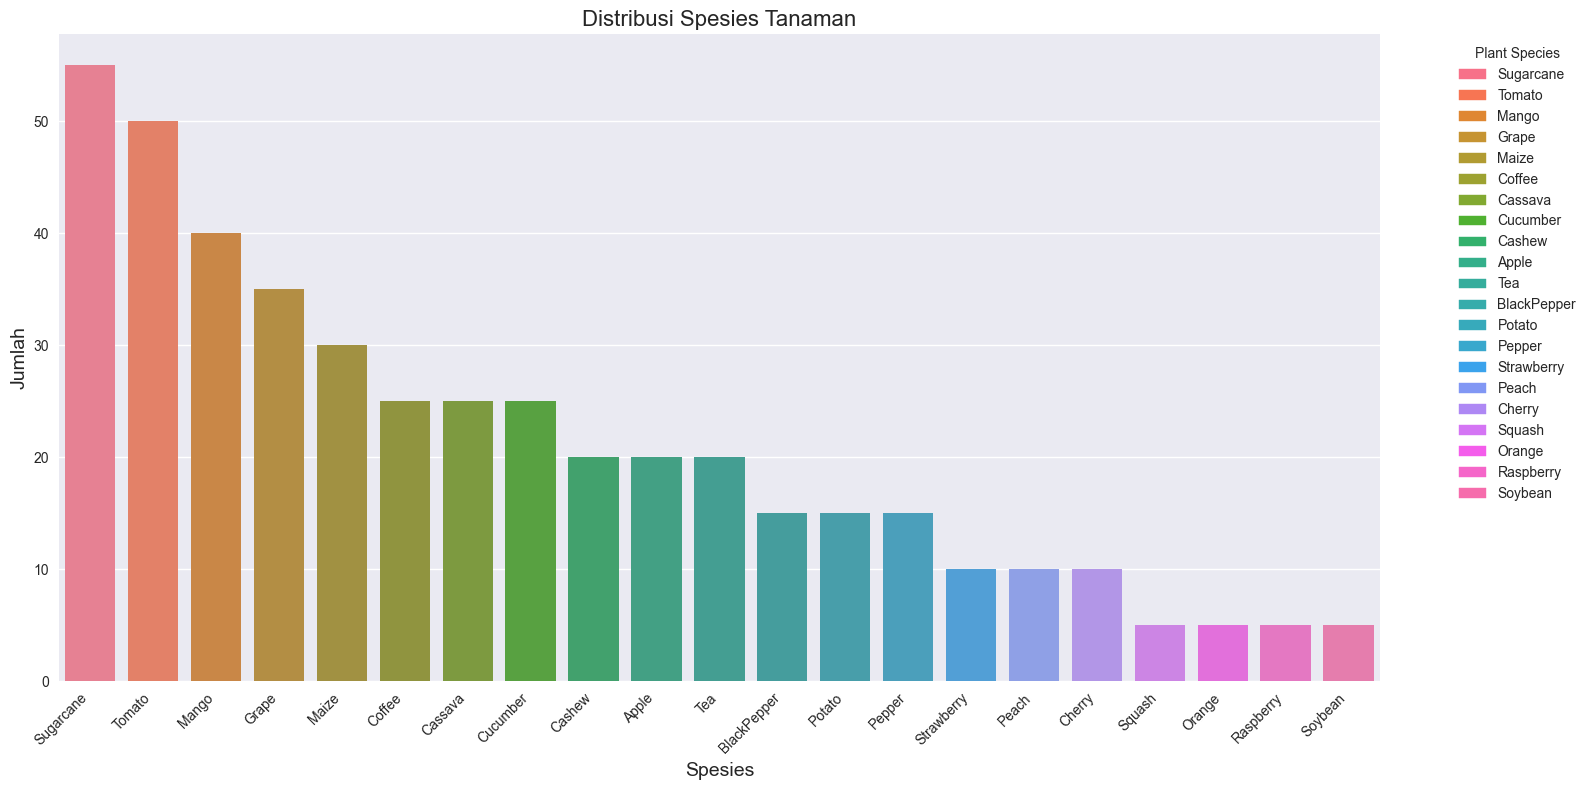

In [ ]:
# Extract species name from label
df['species'] = df['label'].str.rsplit('_', n=1).str[0]

# Count species occurrences
species_counts = df['species'].value_counts().reset_index()
species_counts.columns = ['species', 'count']

# Create color palette
palette = sns.color_palette("husl", len(species_counts))

# Plot with Seaborn
plt.figure(figsize=(14, 8))
ax = sns.barplot(
    x='species', 
    y='count', 
    data=species_counts,
    palette=palette
)

# Customize plot
plt.title('Distribusi Spesies Tanaman', fontsize=16)
plt.xlabel('Spesies', fontsize=14)
plt.ylabel('Jumlah', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Add legend
legend_handles = [plt.Rectangle((0,0),1,1, color=palette[i]) 
                 for i in range(len(species_counts))]
plt.legend(
    legend_handles, 
    species_counts['species'],
    title='Spesies Tanaman',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

C:\Users\Andakara\AppData\Local\Temp\ipykernel_17672\1697767804.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


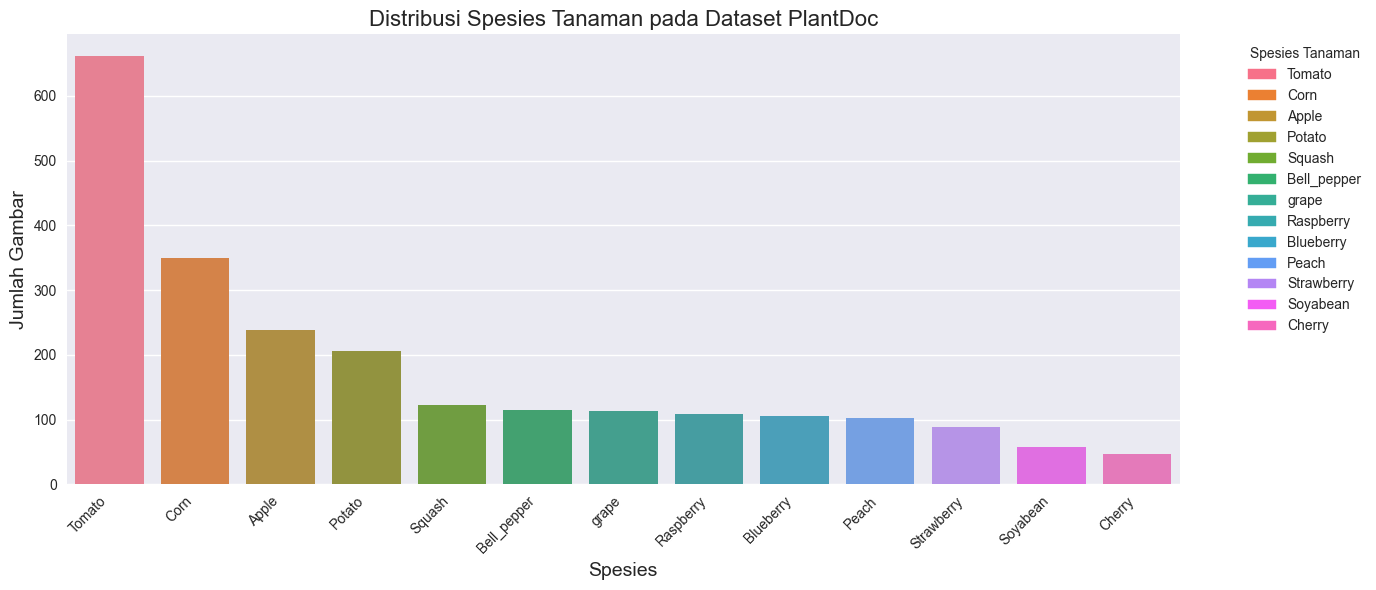

In [30]:
root_dir = "data/PlantDoc-Dataset/train"

species_counts = {}

# Walk through the directory structure
for dir_name in os.listdir(root_dir):
    dir_path = os.path.join(root_dir, dir_name)
    
    # Only process directories
    if os.path.isdir(dir_path):
        # Extract species name (first word before space or underscore)
        species = dir_name.split()[0]
        
        # Count files in the directory
        count = len([f for f in os.listdir(dir_path) 
                    if os.path.isfile(os.path.join(dir_path, f))])
        
        # Aggregate counts by species
        if species in species_counts:
            species_counts[species] += count
        else:
            species_counts[species] = count

# Convert to DataFrame
species_df = pd.DataFrame({
    'species': list(species_counts.keys()),
    'count': list(species_counts.values())
}).sort_values('count', ascending=False)

# Create color palette
palette = sns.color_palette("husl", len(species_df))

# Plot with Seaborn
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x='species', 
    y='count', 
    data=species_df,
    palette=palette
)

# Customize plot
plt.title('Distribusi Spesies Tanaman pada Dataset PlantDoc', fontsize=16)
plt.xlabel('Spesies', fontsize=14)
plt.ylabel('Jumlah Gambar', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()

# Add legend
legend_handles = [plt.Rectangle((0,0),1,1, color=palette[i]) 
                 for i in range(len(species_df))]
plt.legend(
    legend_handles, 
    species_df['species'],
    title='Spesies Tanaman',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=10
)

plt.show()

In [33]:
print(f"Total unique species in LeafNet: {len(leafnet_only)}")
print("Species not found in PlantDoc:")
print(leafnet_only['species'].tolist())

Total unique species in LeafNet: 13
Species not found in PlantDoc:
['Sugarcane', 'Mango', 'Grape', 'Maize', 'Coffee', 'Cassava', 'Cucumber', 'Cashew', 'Tea', 'BlackPepper', 'Pepper', 'Orange', 'Soybean']


C:\Users\Andakara\AppData\Local\Temp\ipykernel_17672\3105020530.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


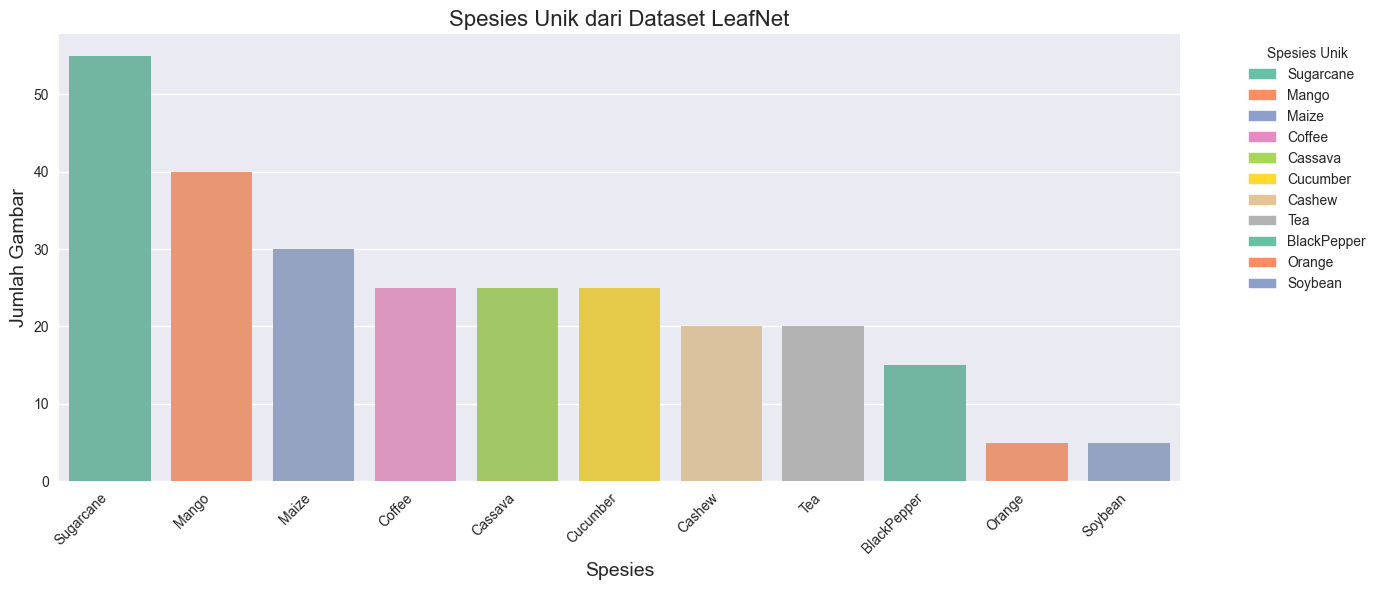

Total unique species in LeafNet: 11
Species not found in PlantDoc:
['Sugarcane', 'Mango', 'Maize', 'Coffee', 'Cassava', 'Cucumber', 'Cashew', 'Tea', 'BlackPepper', 'Orange', 'Soybean']


In [39]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mapping dictionary for PlantDoc to LeafNet species names
SPECIES_MAPPING = {
    'Bell': 'Pepper',      # Map Bell_pepper to Pepper
    'grape': 'Grape',      # Map grape to Grape
    # Add other mappings as needed
}

# Function to get LeafNet species
def get_leafnet_species():
    df = pd.read_parquet("data/leafnet/leafnet_sampled.parquet")
    df['species'] = df['label'].str.rsplit('_', n=1).str[0]
    return df['species'].value_counts().reset_index(name='count')

# Function to get PlantDoc species with normalization
def get_plantdoc_species():
    root_dir = "data/PlantDoc-Dataset/train"
    species_counts = {}
    
    for dir_name in os.listdir(root_dir):
        dir_path = os.path.join(root_dir, dir_name)
        if os.path.isdir(dir_path):
            # Extract base name and apply mapping
            base_name = dir_name.split()[0].split('_')[0]
            species = SPECIES_MAPPING.get(base_name, base_name)
            
            count = len([f for f in os.listdir(dir_path) 
                        if os.path.isfile(os.path.join(dir_path, f))])
            species_counts[species] = species_counts.get(species, 0) + count
    
    return pd.DataFrame({
        'species': list(species_counts.keys()),
        'count': list(species_counts.values())
    })

# Get species data
leafnet_species = get_leafnet_species()
plantdoc_species = get_plantdoc_species()

# Find unique species in LeafNet (case-insensitive comparison)
leafnet_lower = leafnet_species.copy()
leafnet_lower['species_lower'] = leafnet_lower['species'].str.lower()
plantdoc_lower = plantdoc_species.copy()
plantdoc_lower['species_lower'] = plantdoc_lower['species'].str.lower()

leafnet_only = leafnet_lower[
    ~leafnet_lower['species_lower'].isin(plantdoc_lower['species_lower'])
].sort_values('count', ascending=False)

# Create plot
plt.figure(figsize=(12, 6))
palette = sns.color_palette("Set2", len(leafnet_only))

ax = sns.barplot(
    x='species', 
    y='count', 
    data=leafnet_only,
    palette=palette
)

# Customize plot
plt.title('Spesies Unik dari Dataset LeafNet', fontsize=16)
plt.xlabel('Spesies', fontsize=14)
plt.ylabel('Jumlah Gambar', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()

# Add legend
legend_handles = [plt.Rectangle((0,0),1,1, color=palette[i]) 
                 for i in range(len(leafnet_only))]
plt.legend(
    legend_handles, 
    leafnet_only['species'],
    title='Spesies Unik',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=10
)

plt.show()

# Print summary
print(f"Total unique species in LeafNet: {len(leafnet_only)}")
print("Species not found in PlantDoc:")
print(leafnet_only['species'].tolist())

C:\Users\Andakara\AppData\Local\Temp\ipykernel_17672\3798003074.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(
C:\Users\Andakara\AppData\Local\Temp\ipykernel_17672\3798003074.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(


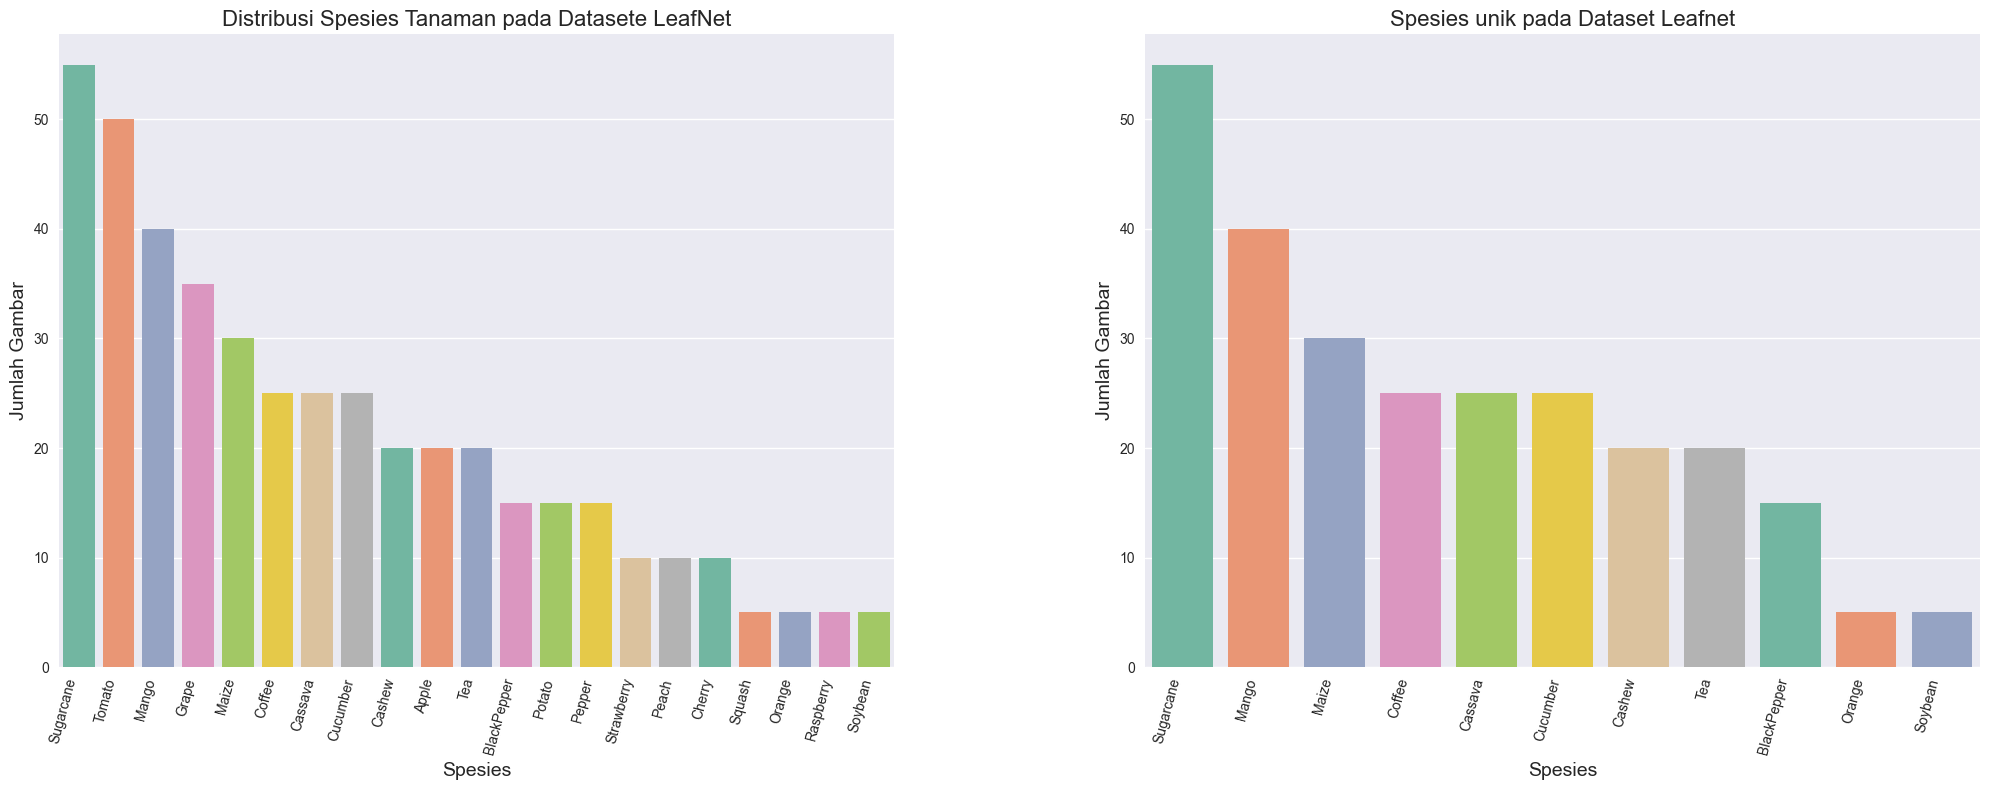

In [44]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mapping dictionary for PlantDoc to LeafNet species names
SPECIES_MAPPING = {
    'Bell': 'Pepper',
    'grape': 'Grape',
}

# Function to get LeafNet species
def get_leafnet_species():
    df = pd.read_parquet("data/leafnet/leafnet_sampled.parquet")
    df['species'] = df['label'].str.rsplit('_', n=1).str[0]
    return df['species'].value_counts().reset_index(name='count')

# Function to get PlantDoc species with normalization
def get_plantdoc_species():
    root_dir = "data/PlantDoc-Dataset/train"
    species_counts = {}
    
    for dir_name in os.listdir(root_dir):
        dir_path = os.path.join(root_dir, dir_name)
        if os.path.isdir(dir_path):
            base_name = dir_name.split()[0].split('_')[0]
            species = SPECIES_MAPPING.get(base_name, base_name)
            count = len([f for f in os.listdir(dir_path) 
                        if os.path.isfile(os.path.join(dir_path, f))])
            species_counts[species] = species_counts.get(species, 0) + count
    
    return pd.DataFrame({
        'species': list(species_counts.keys()),
        'count': list(species_counts.values())
    })

# Get species data
leafnet_species = get_leafnet_species()
plantdoc_species = get_plantdoc_species()

# Normalize for comparison
leafnet_species['species_lower'] = leafnet_species['species'].str.lower()
plantdoc_species['species_lower'] = plantdoc_species['species'].str.lower()

# Find unique species in LeafNet
leafnet_only = leafnet_species[
    ~leafnet_species['species_lower'].isin(plantdoc_species['species_lower'])
].sort_values('count', ascending=False)

# Create figure with two subplots
plt.figure(figsize=(20, 8))

# Subplot 1: Full LeafNet distribution
plt.subplot(1, 2, 1)
palette_full = sns.color_palette("Set2", len(leafnet_species))
ax1 = sns.barplot(
    x='species', 
    y='count', 
    data=leafnet_species.sort_values('count', ascending=False),
    palette=palette_full
)
plt.title('Distribusi Spesies Tanaman pada Datasete LeafNet', fontsize=16)
plt.xlabel('Spesies', fontsize=14)
plt.ylabel('Jumlah Gambar', fontsize=14)
plt.xticks(rotation=75, ha='right', fontsize=10)

# Subplot 2: Unique to LeafNet
plt.subplot(1, 2, 2)
palette_unique = sns.color_palette("Set2", len(leafnet_only))
ax2 = sns.barplot(
    x='species', 
    y='count', 
    data=leafnet_only,
    palette=palette_unique
)
plt.title('Spesies unik pada Dataset Leafnet', fontsize=16)
plt.xlabel('Spesies', fontsize=14)
plt.ylabel('Jumlah Gambar', fontsize=14)
plt.xticks(rotation=75, ha='right', fontsize=10)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()

C:\Users\Andakara\AppData\Local\Temp\ipykernel_17672\2365144470.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Andakara\AppData\Local\Temp\ipykernel_17672\2365144470.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


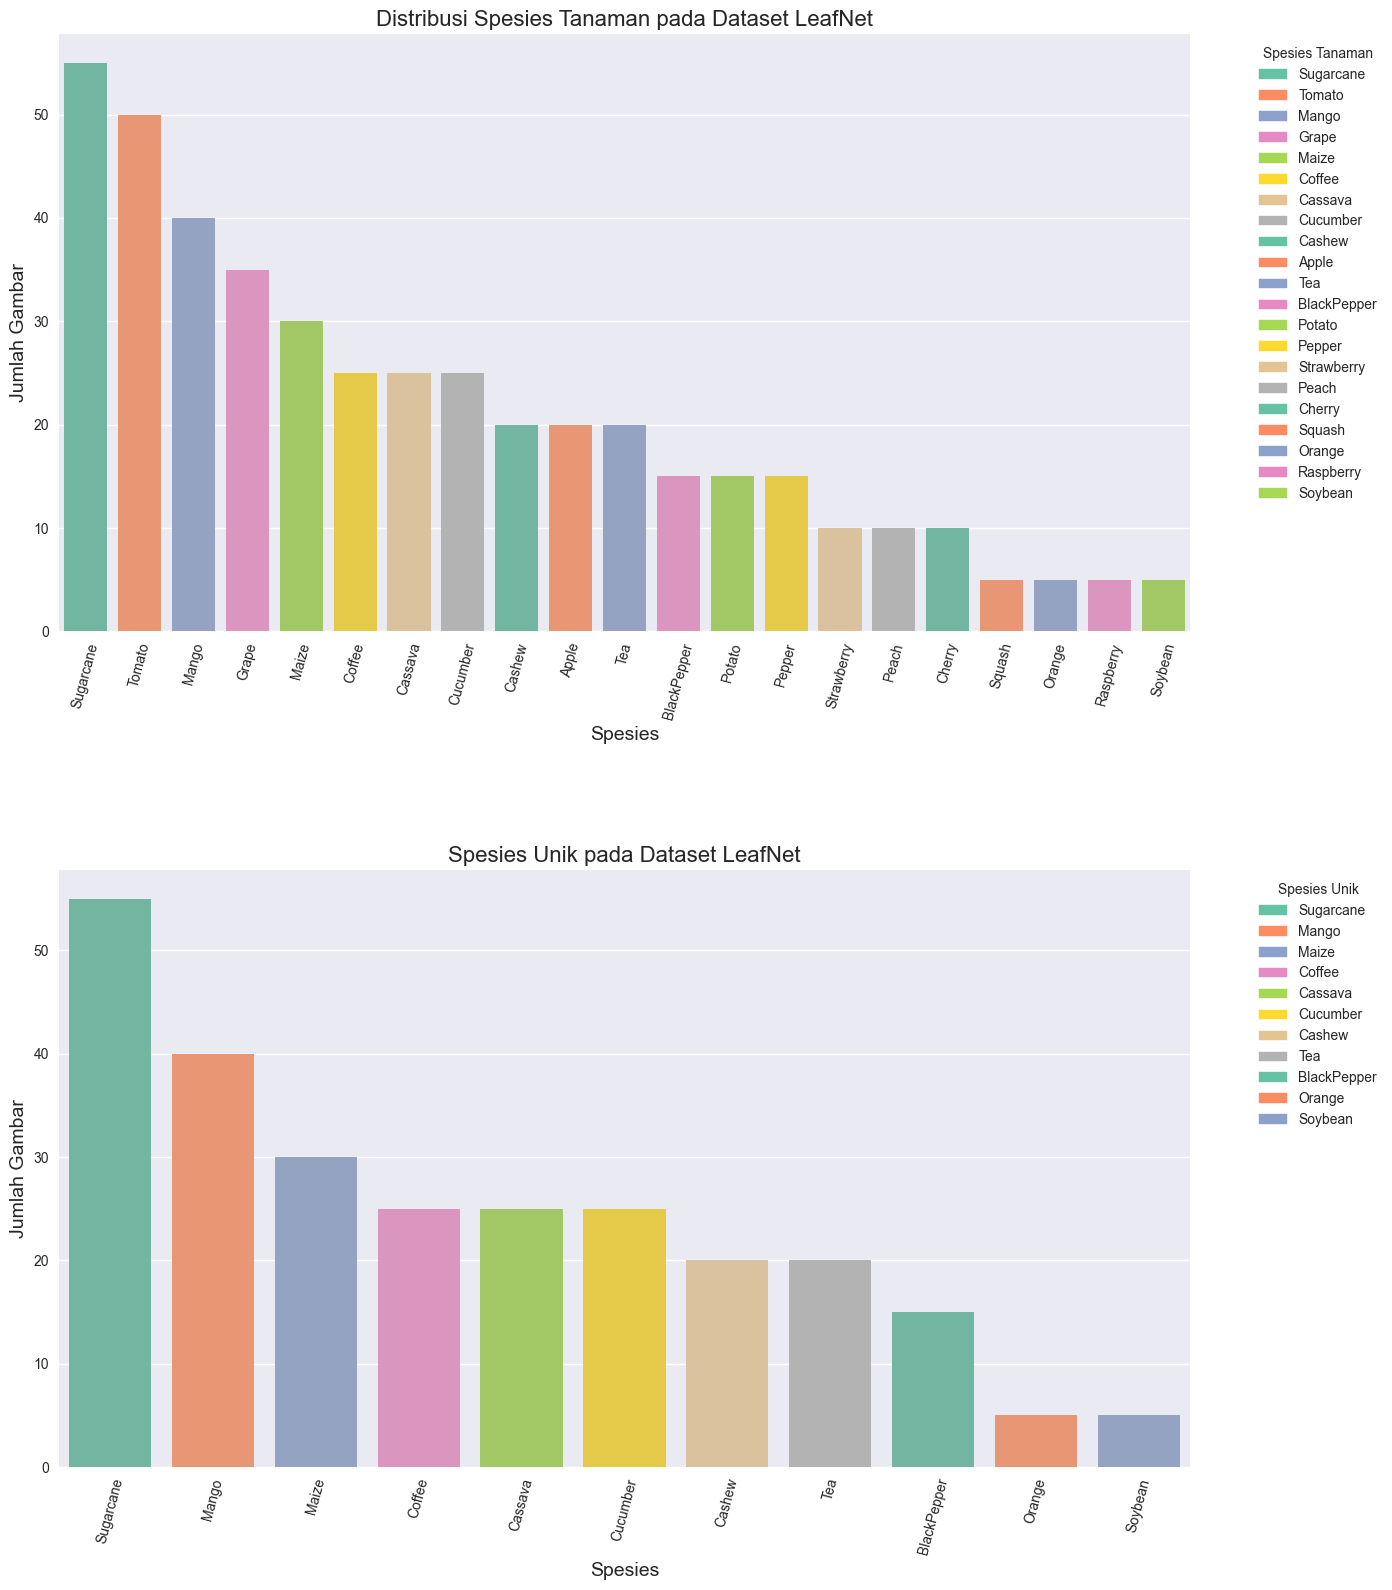

In [47]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mapping dictionary for PlantDoc to LeafNet species names
SPECIES_MAPPING = {
    'Bell': 'Pepper',
    'grape': 'Grape',
}

# Function to get LeafNet species
def get_leafnet_species():
    df = pd.read_parquet("data/leafnet/leafnet_sampled.parquet")
    df['species'] = df['label'].str.rsplit('_', n=1).str[0]
    return df['species'].value_counts().reset_index(name='count')

# Function to get PlantDoc species with normalization
def get_plantdoc_species():
    root_dir = "data/PlantDoc-Dataset/train"
    species_counts = {}
    
    for dir_name in os.listdir(root_dir):
        dir_path = os.path.join(root_dir, dir_name)
        if os.path.isdir(dir_path):
            base_name = dir_name.split()[0].split('_')[0]
            species = SPECIES_MAPPING.get(base_name, base_name)
            count = len([f for f in os.listdir(dir_path) 
                        if os.path.isfile(os.path.join(dir_path, f))])
            species_counts[species] = species_counts.get(species, 0) + count
    
    return pd.DataFrame({
        'species': list(species_counts.keys()),
        'count': list(species_counts.values())
    })

# Get species data
leafnet_species = get_leafnet_species()
plantdoc_species = get_plantdoc_species()

# Normalize for comparison
leafnet_species['species_lower'] = leafnet_species['species'].str.lower()
plantdoc_species['species_lower'] = plantdoc_species['species'].str.lower()

# Find unique species in LeafNet
leafnet_only = leafnet_species[
    ~leafnet_species['species_lower'].isin(plantdoc_species['species_lower'])
].sort_values('count', ascending=False)

# Create vertical subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 16))

# Plot 1: Full LeafNet distribution (top)
palette_full = sns.color_palette("Set2", len(leafnet_species))
sns.barplot(
    x='species', 
    y='count', 
    data=leafnet_species.sort_values('count', ascending=False),
    palette=palette_full,
    ax=ax1
)
ax1.set_title('Distribusi Spesies Tanaman pada Dataset LeafNet', fontsize=16)
ax1.set_xlabel('Spesies', fontsize=14)
ax1.set_ylabel('Jumlah Gambar', fontsize=14)
ax1.tick_params(axis='x', rotation=75, labelsize=10)

# Add legend for Plot 1
legend_handles1 = [plt.Rectangle((0,0),1,1, color=palette_full[i]) 
                  for i in range(len(leafnet_species))]
ax1.legend(
    legend_handles1, 
    leafnet_species['species'],
    title='Spesies Tanaman',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=10
)

# Plot 2: Unique to LeafNet (bottom)
palette_unique = sns.color_palette("Set2", len(leafnet_only))
sns.barplot(
    x='species', 
    y='count', 
    data=leafnet_only,
    palette=palette_unique,
    ax=ax2
)
ax2.set_title('Spesies Unik pada Dataset LeafNet', fontsize=16)
ax2.set_xlabel('Spesies', fontsize=14)
ax2.set_ylabel('Jumlah Gambar', fontsize=14)
ax2.tick_params(axis='x', rotation=75, labelsize=10)

# Add legend for Plot 2
legend_handles2 = [plt.Rectangle((0,0),1,1, color=palette_unique[i]) 
                  for i in range(len(leafnet_only))]
ax2.legend(
    legend_handles2, 
    leafnet_only['species'],
    title='Spesies Unik',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=10
)

plt.tight_layout()
plt.subplots_adjust(hspace=0.4)  # Add vertical space between plots
plt.show()